# Modelos predictores de Implied Volatility







El **objetivo** de este notebook es aplicar diversos modelos y técnicas de IA y RRNN para encontrar el mejor modelo capaz de hacer una predicción con el mínimo error de la Volatilidad Implícita de trades de opciones del IBEX 35.

In [1]:
from src.volatility_models.data_utils import TrainingDataHandler

from src.volatility_models.training_utils import Trainer
from src.python_models.volatility_models.volatility_model_family import (
    LinearRegressionFamily,
    RandomForestFamily,
    XGBoostFamily,
    SequentialNNFamily,
    QuantumInspiredNNFamily,
)
from src.python_models.volatility_models.volatility_model_family import TrainingPhase

## Selección de variables, Splits y  Feature Engineering

In [ ]:
# Columnas escogidas para features + target + auditoría
volatility_df = TrainingDataHandler.load_volatility_db()
print("Rows loaded:", len(volatility_df))
display(volatility_df.head())

Adicionalmente, hay que crear un catálogo de las variables categóricas porque hay que aplicarle one-hot encoding.

In [ ]:
train_df, val_df, test_df = TrainingDataHandler.load_splitted_data()

In [ ]:
train_df, val_df, test_df = TrainingDataHandler.load_full_features_splitted_data()
trainval_df, final_test_df = TrainingDataHandler.load_full_features_trainval_test_data()

In [ ]:
folds = TrainingDataHandler.load_kfolds()

# Fase CV

2026-05-06 15:52:46,975 | INFO | src.python_models.volatility_models.volatility_model_family | Family 'linear_regression' has no hyperparameters to explore. A single model will be trained with the fixed parameters.
2026-05-06 15:52:51,771 | INFO | src.volatility_models.data_utils | Train/Val/Test split | rows: train=243791 [2017-01-02 -> 2020-11-09]  val=26093 [2020-12-01 -> 2021-08-10]  test=36973 [2021-09-01 -> 2022-06-28]  total=306857
Training family: linear_regression: 100%|██████████| 1/1 [00:00<00:00,  4.18it/s]
2026-05-06 15:52:52,431 | INFO | src.volatility_models.visualization_utils | Showing top 15 family models
                   custom_error1  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2  train_mae_std  train_rmse_std  train_r2_std  val_mae_std  val_rmse_std  val_r2_std
linear_regression       0.107115   0.038924    0.099235  0.245322  0.055272  0.097352 -0.040135       0.005003        0.015803      0.047068     0.032407      0.039053    0.170116


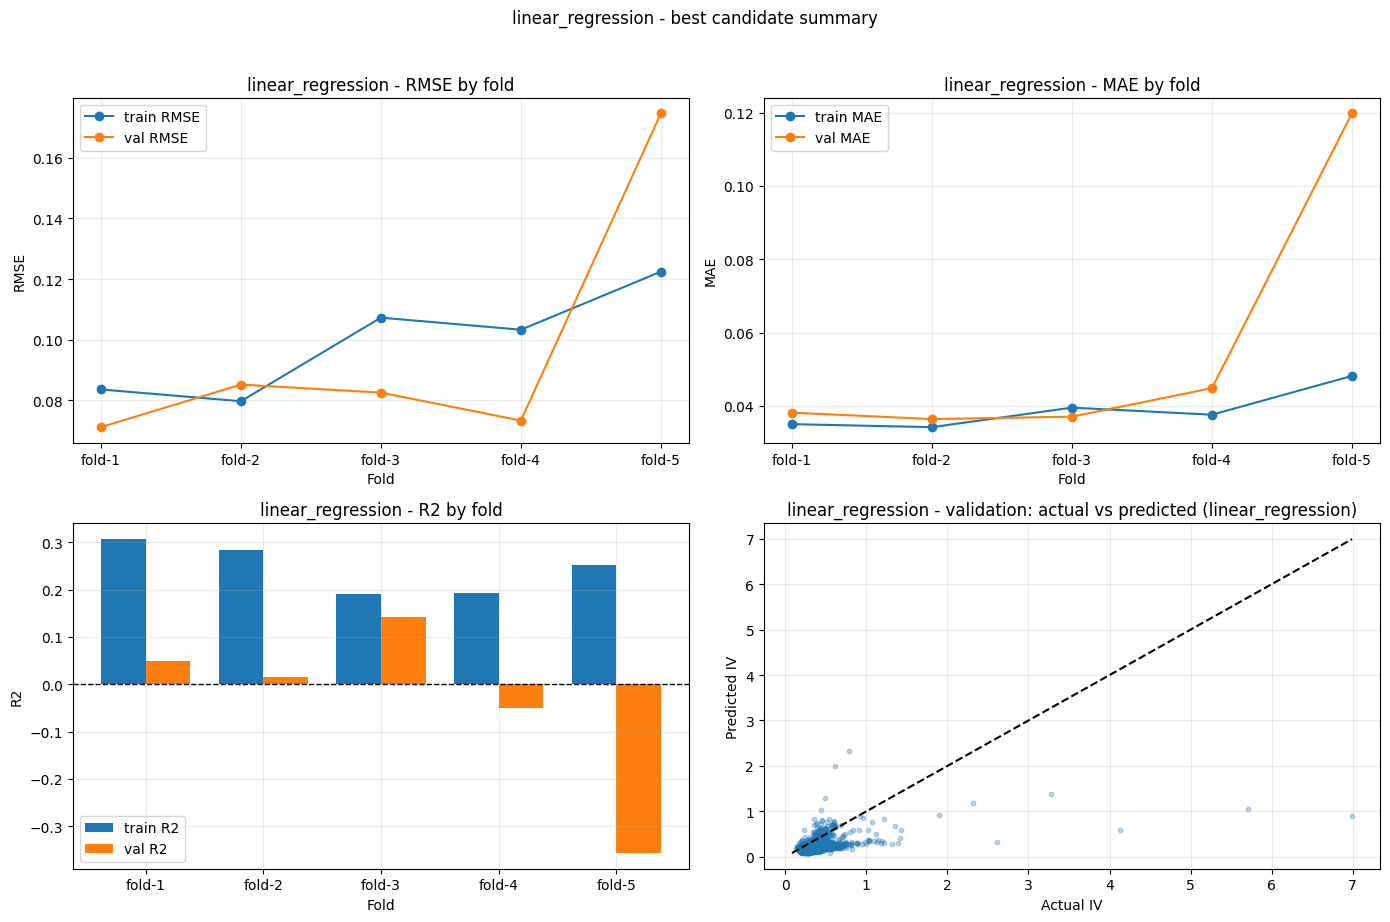

2026-05-06 15:52:53,230 | INFO | src.volatility_models.visualization_utils | Metadata saved: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\family_metadata\linear_regression_metadata.json


In [2]:
linear_models_metrics_table, linear_best_model_name = Trainer(LinearRegressionFamily).run_kfolds_training()

In [ ]:
random_forest_models_metrics_table, random_forest_best_model_name = Trainer(RandomForestFamily).run_kfolds_training()

2026-05-06 15:52:53,248 | INFO | src.python_models.volatility_models.volatility_model_family | Hyperparameter exploration for 'xgboost': 200/102060000 configurations (0.00%).
2026-05-06 15:52:58,088 | INFO | src.volatility_models.data_utils | Train/Val/Test split | rows: train=243791 [2017-01-02 -> 2020-11-09]  val=26093 [2020-12-01 -> 2021-08-10]  test=36973 [2021-09-01 -> 2022-06-28]  total=306857
Training family: xgboost: 100%|██████████| 200/200 [1:08:27<00:00, 20.54s/it]
2026-05-06 17:01:25,663 | INFO | src.volatility_models.visualization_utils | Showing top 15 family models
             custom_error1  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2  train_mae_std  train_rmse_std  train_r2_std  val_mae_std  val_rmse_std  val_r2_std
xgboost_118       0.075080   0.023451    0.047822  0.827083  0.041597  0.058484  0.638769       0.003210        0.011425      0.032065     0.029506      0.034398    0.181273
xgboost_116       0.075799   0.023342    0.045262  0.844482  0.04

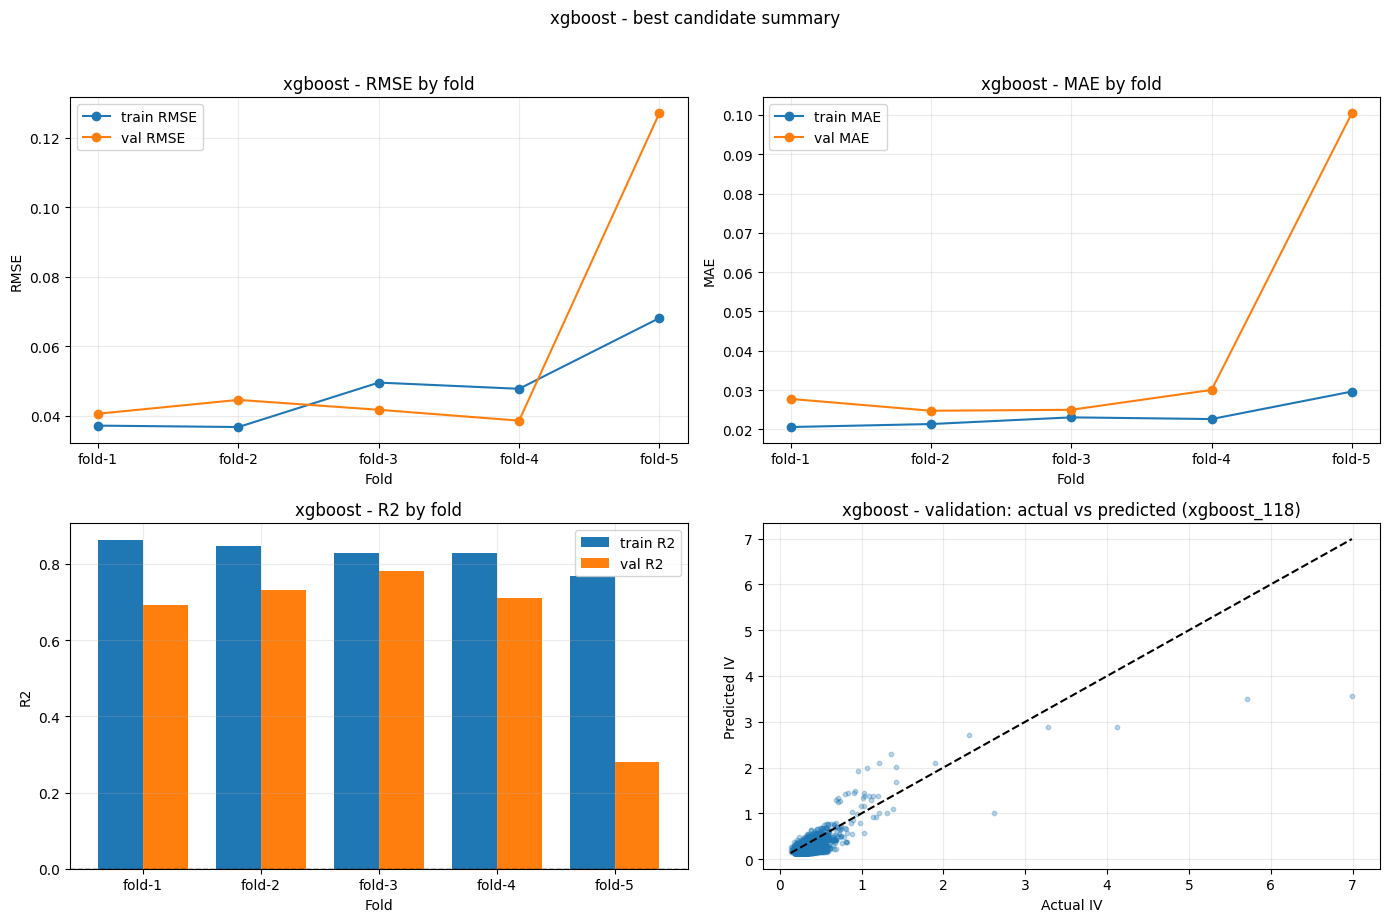

2026-05-06 17:02:11,227 | INFO | src.volatility_models.visualization_utils | Metadata saved: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\family_metadata\xgboost_metadata.json


In [3]:
xgboost_models_metrics_table, xgboost_best_model_name = Trainer(XGBoostFamily).run_kfolds_training()

2026-05-06 17:36:44,141 | INFO | src.python_models.volatility_models.volatility_model_family | Hyperparameter exploration for 'sequential_nn': 1/400000 configurations (0.00%).
2026-05-06 17:36:48,411 | INFO | src.volatility_models.data_utils | Train/Val/Test split | rows: train=243791 [2017-01-02 -> 2020-11-09]  val=26093 [2020-12-01 -> 2021-08-10]  test=36973 [2021-09-01 -> 2022-06-28]  total=306857
Training family: sequential_nn: 100%|██████████| 1/1 [03:39<00:00, 219.75s/it]
2026-05-06 17:40:28,459 | INFO | src.volatility_models.visualization_utils | Showing top 15 family models
                   custom_error1  train_mae  train_rmse  train_r2  val_mae  val_rmse    val_r2  train_mae_std  train_rmse_std  train_r2_std  val_mae_std  val_rmse_std  val_r2_std
sequential_nn_001       0.095276   0.032144    0.087758  0.409227  0.04897  0.086043  0.197049       0.003656        0.013466      0.024898     0.032391       0.03693    0.164511


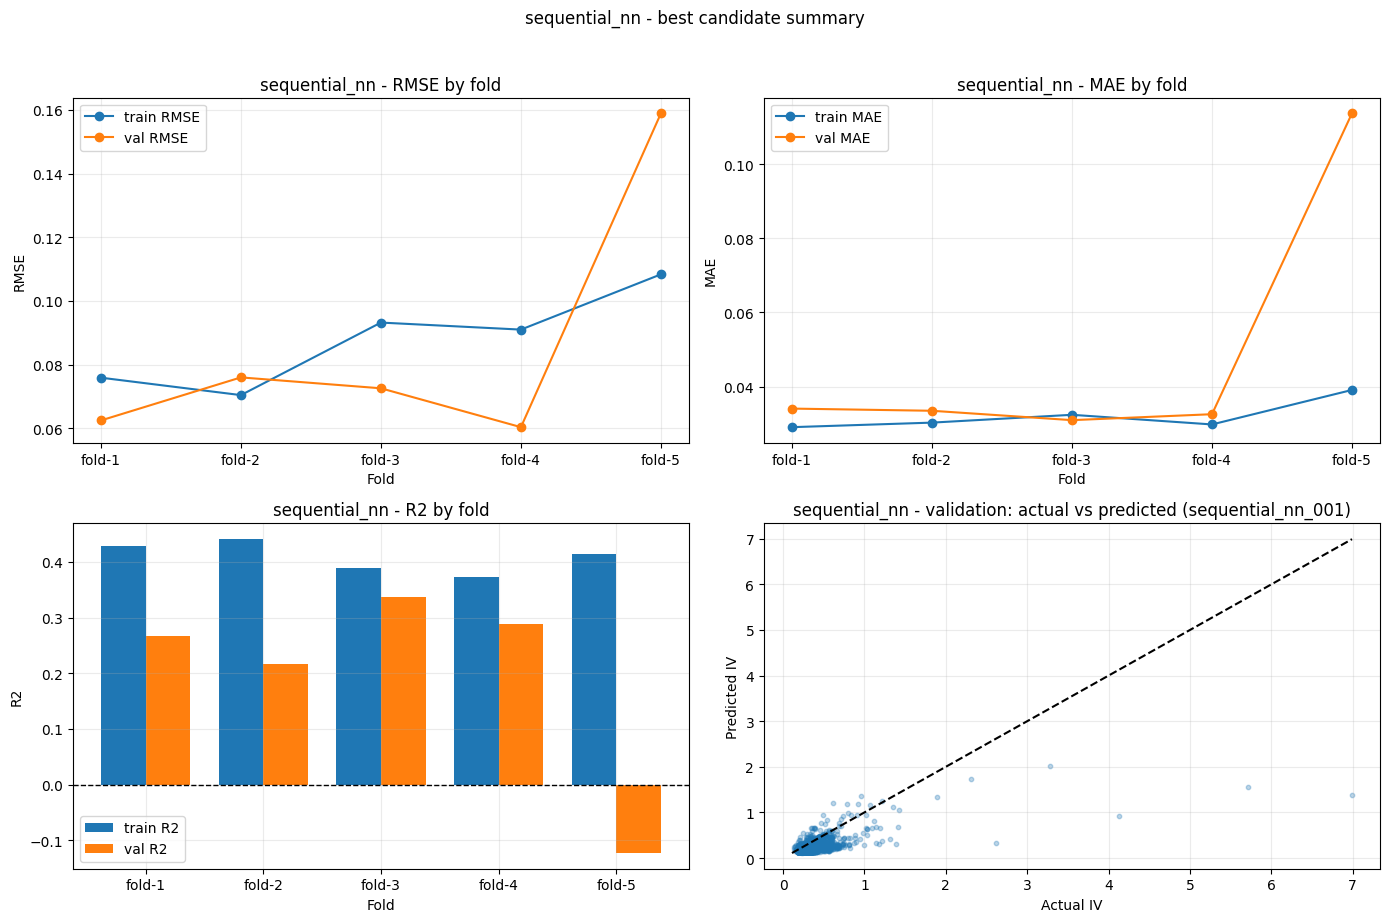

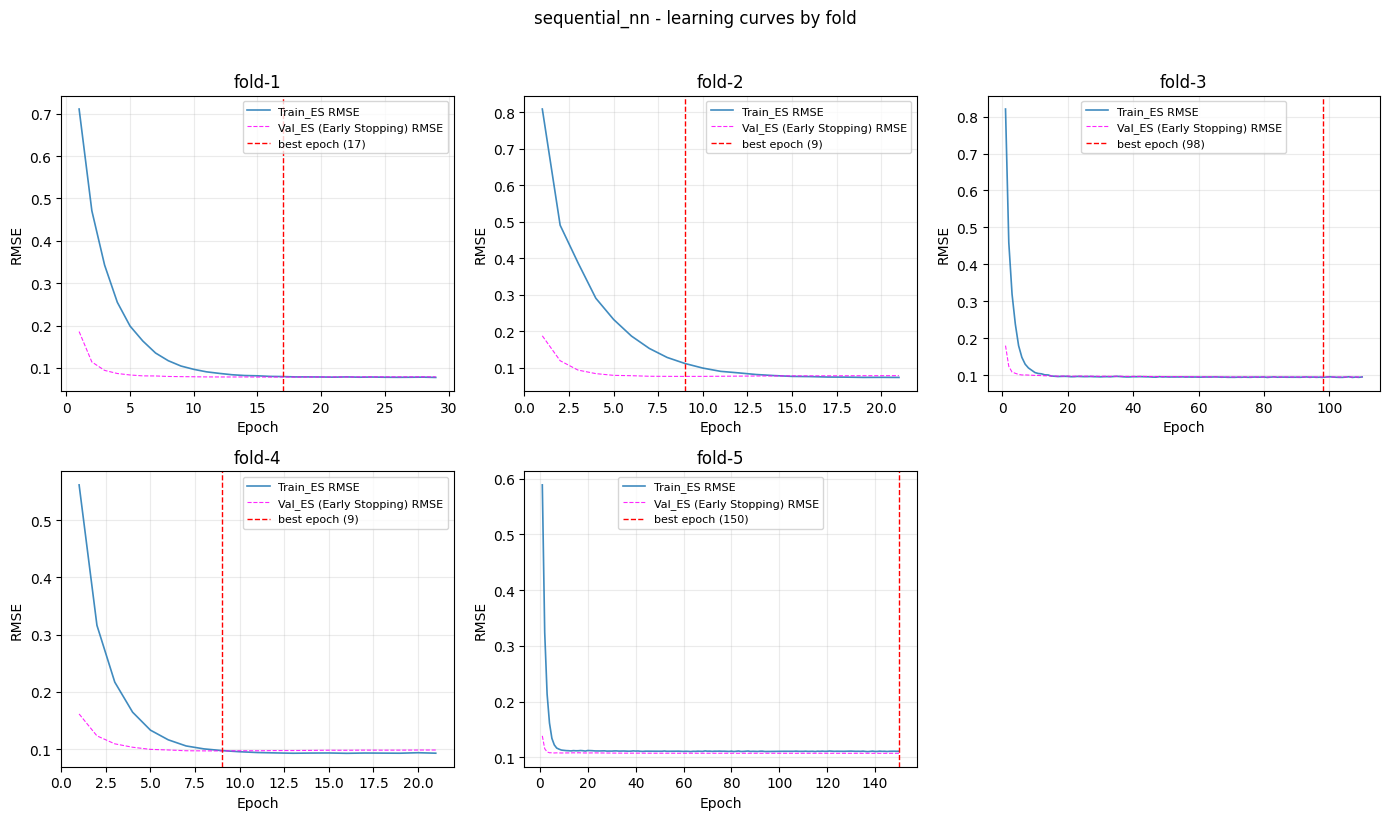

2026-05-06 17:40:29,417 | INFO | src.volatility_models.visualization_utils | Metadata saved: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\family_metadata\sequential_nn_metadata.json


In [2]:
sequential_nn_models_metrics_table, sequential_nn_best_model_name = Trainer(SequentialNNFamily).run_kfolds_training()

In [ ]:
quantum_inspired_nn_models_metrics_table, quantum_inspired_nn_best_model_name = Trainer(QuantumInspiredNNFamily).run_kfolds_training()

# Reentrenamiento de la mejor parametrización de cada familia

In [4]:
linear_best_model_metrics = Trainer(LinearRegressionFamily).retrain_best_params_family()

2026-05-06 17:02:19,980 | INFO | src.volatility_models.data_utils | Train/Val/Test split | rows: train=243791 [2017-01-02 -> 2020-11-09]  val=26093 [2020-12-01 -> 2021-08-10]  test=36973 [2021-09-01 -> 2022-06-28]  total=306857
2026-05-06 17:02:19,982 | INFO | src.volatility_models.training_utils | Training: Retraining 'linear_regression' | phase=train_val | input fit: train_rows=243791 eval_rows=26093 total_rows=269884
2026-05-06 17:02:20,082 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining:
                custom_error2  train_mae   val_mae  train_rmse  val_rmse  train_r2    val_r2
retrained_best       0.136026   0.058647  0.045267    0.128955  0.109247  0.252617  0.181107
2026-05-06 17:02:20,168 | INFO | src.volatility_models.visualization_utils | Retraining metadata saved: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\linear_regression_train_val_retrained_metadata.json


In [ ]:
random_forest_best_model_metrics = Trainer(RandomForestFamily).retrain_best_params_family()

In [5]:
xgboost_best_model_metrics = Trainer(XGBoostFamily).retrain_best_params_family()

2026-05-06 17:02:33,642 | INFO | src.volatility_models.data_utils | Train/Val/Test split | rows: train=243791 [2017-01-02 -> 2020-11-09]  val=26093 [2020-12-01 -> 2021-08-10]  test=36973 [2021-09-01 -> 2022-06-28]  total=306857
2026-05-06 17:02:33,644 | INFO | src.volatility_models.training_utils | Training: Retraining 'xgboost' | phase=train_val | input fit: train_rows=243791 eval_rows=26093 total_rows=269884
2026-05-06 17:02:38,903 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining:
                custom_error2  train_mae   val_mae  train_rmse  val_rmse  train_r2    val_r2
retrained_best       0.089013   0.038279  0.042297    0.074852  0.070243  0.748193  0.661459
2026-05-06 17:02:39,017 | INFO | src.volatility_models.visualization_utils | Retraining metadata saved: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\xgboost_train_val_retrained_metadata.json


In [ ]:
sequential_nn_best_model_metrics = Trainer(SequentialNNFamily).retrain_best_params_family()

In [ ]:
quantum_inspired_nn_best_model_metrics = Trainer(QuantumInspiredNNFamily).retrain_best_params_family()

# Reentrenamiento para posterior test

In [ ]:
linear_best_model_metrics_test = Trainer(LinearRegressionFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=True)

In [ ]:
random_forest_best_model_metrics_test = Trainer(RandomForestFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=True)

In [ ]:
xgboost_best_model_metrics_test = Trainer(XGBoostFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=True)

In [ ]:
sequential_nn_best_model_metrics_test = Trainer(SequentialNNFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=True)

In [ ]:
quantum_inspired_nn_best_model_metrics_test = Trainer(QuantumInspiredNNFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=True)

# Reentrenamiento progresivo de la mejor parametrización de cada familia

In [ ]:
linear_best_model_metrics_progressive = Trainer(LinearRegressionFamily).retrain_best_params_family(phase=TrainingPhase.TRAIN_VAL, progressive_training=True)

In [ ]:
random_forest_best_model_metrics_progressive = Trainer(RandomForestFamily).retrain_best_params_family(phase=TrainingPhase.TRAIN_VAL, progressive_training=True)

In [ ]:
xgboost_best_model_metrics_progressive = Trainer(XGBoostFamily).retrain_best_params_family(phase=TrainingPhase.TRAIN_VAL, progressive_training=True)

In [ ]:
sequential_nn_best_model_metrics_progressive = Trainer(SequentialNNFamily).retrain_best_params_family(phase=TrainingPhase.TRAIN_VAL, progressive_training=True)

In [ ]:
quantum_inspired_nn_best_model_metrics_progressive = Trainer(QuantumInspiredNNFamily).retrain_best_params_family(phase=TrainingPhase.TRAIN_VAL, progressive_training=True)

# Reentrenamiento progresivo para posterior test

In [ ]:
linear_best_model_metrics_test_progressive = Trainer(LinearRegressionFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=True, progressive_training=True)

In [ ]:
random_forest_best_model_metrics_test_progressive = Trainer(RandomForestFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=True, progressive_training=True)

In [ ]:
xgboost_best_model_metrics_test_progressive = Trainer(XGBoostFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=True, progressive_training=True)

In [ ]:
sequential_nn_best_model_metrics_test_progressive = Trainer(SequentialNNFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=True, progressive_training=True)

In [ ]:
quantum_inspired_nn_best_model_metrics_test_progressive = Trainer(QuantumInspiredNNFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=True, progressive_training=True)